In [27]:
!pip install pretty_midi miditok

In [28]:
import os
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pretty_midi
from miditok import REMI, TokenizerConfig
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import torch
from torch.utils.data import Dataset, DataLoader

In [29]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [30]:
def get_device():
    if torch.cuda.is_available():
        return torch.device('cuda')
    elif getattr(torch.backends, 'mps', None) and torch.backends.mps.is_available():
        return torch.device('mps')
    return torch.device('cpu')

device = get_device()
print('PyTorch version:', torch.__version__)
print('WE GOT THE:', device)

PyTorch version: 2.10.0+cpu
WE GOT THE: cpu


In [31]:
# --- Paths ---
BASE_PATH          = Path('/content/drive/MyDrive/CSE425 Project')
csv_path           = BASE_PATH / 'data' / 'maestro-v3.0.0.csv'
midi_root          = BASE_PATH / 'data' / 'raw_data'
tokenized_path     = BASE_PATH / 'data' / 'tokenized'
tokenized_path.mkdir(parents=True, exist_ok=True)
plots_path         = BASE_PATH / 'output' / 'tokenization'
plots_path.mkdir(parents=True, exist_ok=True)

print(f'CSV          : {csv_path}')
print(f'MIDI root    : {midi_root}')
print(f'Tokenized out: {tokenized_path}')
print(f'Plots out    : {plots_path}')

CSV          : /content/drive/MyDrive/CSE425 Project/data/maestro-v3.0.0.csv
MIDI root    : /content/drive/MyDrive/CSE425 Project/data/raw_data
Tokenized out: /content/drive/MyDrive/CSE425 Project/data/tokenized
Plots out    : /content/drive/MyDrive/CSE425 Project/output/tokenization


In [ ]:
MAX_SEQ_LEN    = 512
STRIDE         = 256
VELOCITY_BINS  = 32

GENRE_MAP = {
    # Baroque / Classical
    'Bach'       : 0, 'Handel'     : 0, 'Scarlatti'  : 0,
    'Haydn'      : 0, 'Mozart'     : 0, 'Clementi'   : 0,
    # Romantic
    'Beethoven'  : 1, 'Schubert'   : 1, 'Chopin'     : 1,
    'Schumann'   : 1, 'Liszt'      : 1, 'Brahms'     : 1,
    'Mendelssohn': 1, 'Grieg'      : 1, 'Tchaikovsky': 1,
    # 20th Century / Modern
    'Debussy'    : 2, 'Ravel'      : 2, 'Scriabin'   : 2,
    'Prokofiev'  : 2, 'Bartok'     : 2, 'Rachmaninoff': 2,
    'Schoenberg' : 2, 'Kapustin'   : 2,
}
NUM_GENRES = 3
DEFAULT_GENRE = 1

print('Config loaded.')
print(f'  MAX_SEQ_LEN  : {MAX_SEQ_LEN}')
print(f'  STRIDE       : {STRIDE}')
print(f'  VELOCITY_BINS: {VELOCITY_BINS}')
print(f'  NUM_GENRES   : {NUM_GENRES}')

Config loaded.
  MAX_SEQ_LEN  : 512
  STRIDE       : 256
  VELOCITY_BINS: 32
  NUM_GENRES   : 3


### Build the REMI Tokenizer

In [ ]:
tokenizer_config = TokenizerConfig(
    num_velocities=VELOCITY_BINS,
    use_chords=False,
    use_rests=False,
    use_tempos=False,
    use_programs=False,
)
tokenizer = REMI(tokenizer_config)

VOCAB_SIZE = len(tokenizer)
PAD_ID     = tokenizer['PAD_None'] if 'PAD_None' in tokenizer.vocab else 0
BOS_ID     = tokenizer['BOS_None'] if 'BOS_None' in tokenizer.vocab else None
EOS_ID     = tokenizer['EOS_None'] if 'EOS_None' in tokenizer.vocab else None

print(f'Tokenizer ready. Vocab size: {VOCAB_SIZE}')
print(f'PAD id: {PAD_ID} | BOS id: {BOS_ID} | EOS id: {EOS_ID}')

tokenizer_save_path = str(tokenized_path / 'remi_tokenizer')
tokenizer.save_pretrained(tokenizer_save_path)
print(f'Tokenizer saved to {tokenizer_save_path}')

Tokenizer ready. Vocab size: 284
PAD id: 0 | BOS id: 1 | EOS id: 2
Tokenizer saved to /content/drive/MyDrive/CSE425 Project/data/tokenized/remi_tokenizer


In [ ]:
token_config_dict = {
    'vocab_size'   : VOCAB_SIZE,
    'pad_id'       : PAD_ID,
    'bos_id'       : BOS_ID,
    'eos_id'       : EOS_ID,
    'max_seq_len'  : MAX_SEQ_LEN,
    'stride'       : STRIDE,
    'num_genres'   : NUM_GENRES,
    'velocity_bins': VELOCITY_BINS,
}
config_save_path = tokenized_path / 'token_config.json'
with open(config_save_path, 'w') as f:
    json.dump(token_config_dict, f, indent=2)
print(f'Token config saved to {config_save_path}')

Token config saved to /content/drive/MyDrive/CSE425 Project/data/tokenized/token_config.json


### Helper: Assign Genre Label from Composer Name

In [ ]:
def get_genre_label(composer_str):
    if not isinstance(composer_str, str):
        return DEFAULT_GENRE
    for name, label in GENRE_MAP.items():
        if name.lower() in composer_str.lower():
            return label
    return DEFAULT_GENRE

### Core Tokenization Function

In [ ]:
def tokenize_split(split_name, df):
    split_df = df[df['split'] == split_name]
    all_windows = []
    all_genres  = []

    print(f'\nProcessing {split_name} split ({len(split_df)} files)...')

    for _, row in tqdm(split_df.iterrows(), total=len(split_df)):
        midi_path = midi_root / row['midi_filename']

        if not midi_path.exists():
            continue

        try:
            tok_seq = tokenizer(str(midi_path))

            if isinstance(tok_seq, list):
                ids = tok_seq[0].ids
            else:
                ids = tok_seq.ids

            if len(ids) < 10:
                continue

            genre_label = get_genre_label(row.get('canonical_composer', ''))

            for start in range(0, len(ids), STRIDE):
                window = ids[start : start + MAX_SEQ_LEN]

                if len(window) < MAX_SEQ_LEN // 4:
                    continue

                if len(window) < MAX_SEQ_LEN:
                    window = window + [PAD_ID] * (MAX_SEQ_LEN - len(window))

                all_windows.append(window)
                all_genres.append(genre_label)

        except Exception:
            continue

    if all_windows:
        tokens_array = np.array(all_windows, dtype=np.int32) 
        genres_array = np.array(all_genres,  dtype=np.int32) 

        tokens_path = tokenized_path / f'tokens_{split_name}.npy'
        genres_path = tokenized_path / f'genres_{split_name}.npy'

        np.save(tokens_path, tokens_array)
        np.save(genres_path, genres_array)

        genre_counts = np.bincount(genres_array, minlength=NUM_GENRES)
        print(f'WE GOT THIS')
        print(f'  {len(tokens_array)} windows saved to {tokens_path}')
        print(f'  Genre distribution -> Baroque/Classical: {genre_counts[0]} | '
              f'Romantic: {genre_counts[1]} | 20th Century: {genre_counts[2]}')
    else:
        print(f'No windows produced for {split_name} split.')

### Run Tokenization for All Splits

In [37]:
maestro_df = pd.read_csv(csv_path)
print(f'CSV loaded. Total rows: {len(maestro_df)}')
print(f'Splits: {maestro_df["split"].value_counts().to_dict()}')

for split in ['train', 'validation', 'test']:
    tokenize_split(split, maestro_df)

CSV loaded. Total rows: 1276
Splits: {'train': 962, 'test': 177, 'validation': 137}

Processing train split (962 files)...


100%|██████████| 962/962 [02:25<00:00,  6.59it/s]


WE GOT THIS
  80449 windows saved to /content/drive/MyDrive/CSE425 Project/data/tokenized/tokens_train.npy
  Genre distribution -> Baroque/Classical: 9922 | Romantic: 63865 | 20th Century: 6662

Processing validation split (137 files)...


100%|██████████| 137/137 [00:15<00:00,  8.62it/s]


WE GOT THIS
  9103 windows saved to /content/drive/MyDrive/CSE425 Project/data/tokenized/tokens_validation.npy
  Genre distribution -> Baroque/Classical: 1050 | Romantic: 6930 | 20th Century: 1123

Processing test split (177 files)...


100%|██████████| 177/177 [00:16<00:00, 10.80it/s]


WE GOT THIS
  10487 windows saved to /content/drive/MyDrive/CSE425 Project/data/tokenized/tokens_test.npy
  Genre distribution -> Baroque/Classical: 1258 | Romantic: 7999 | 20th Century: 1230


### Verify Saved Files

In [38]:
print('\n=== Verification ===')
for split in ['train', 'validation', 'test']:
    t_path = tokenized_path / f'tokens_{split}.npy'
    g_path = tokenized_path / f'genres_{split}.npy'
    if t_path.exists():
        t = np.load(t_path)
        g = np.load(g_path)
        genre_counts = np.bincount(g, minlength=NUM_GENRES)
        print(f'{split:12s}: tokens shape={t.shape}, dtype={t.dtype}')
        print(f'             genres shape={g.shape}, unique={np.unique(g).tolist()}')
        print(f'             Genre split -> [0]Baroque/Classical={genre_counts[0]} '
              f'[1]Romantic={genre_counts[1]} [2]20thCentury={genre_counts[2]}')
        # Sanity check: no tokens should be negative or exceed vocab size
        assert t.min() >= 0, 'Negative token IDs found!'
        assert t.max() < VOCAB_SIZE, f'Token ID {t.max()} >= vocab size {VOCAB_SIZE}!'
        print(f'             Token range: [{t.min()}, {t.max()}] (vocab size={VOCAB_SIZE}) OK')
    else:
        print(f'{split:12s}: FILE NOT FOUND')
print('\nDone!')


=== Verification ===
train       : tokens shape=(80449, 512), dtype=int32
             genres shape=(80449,), unique=[0, 1, 2]
             Genre split -> [0]Baroque/Classical=9922 [1]Romantic=63865 [2]20thCentury=6662
             Token range: [0, 221] (vocab size=284) OK
validation  : tokens shape=(9103, 512), dtype=int32
             genres shape=(9103,), unique=[0, 1, 2]
             Genre split -> [0]Baroque/Classical=1050 [1]Romantic=6930 [2]20thCentury=1123
             Token range: [0, 221] (vocab size=284) OK
test        : tokens shape=(10487, 512), dtype=int32
             genres shape=(10487,), unique=[0, 1, 2]
             Genre split -> [0]Baroque/Classical=1258 [1]Romantic=7999 [2]20thCentury=1230
             Token range: [0, 221] (vocab size=284) OK

Done!


### EDA: Token Distribution and Genre Breakdown

EDA plot saved to /content/drive/MyDrive/CSE425 Project/output/tokenization/tokenization_eda.png


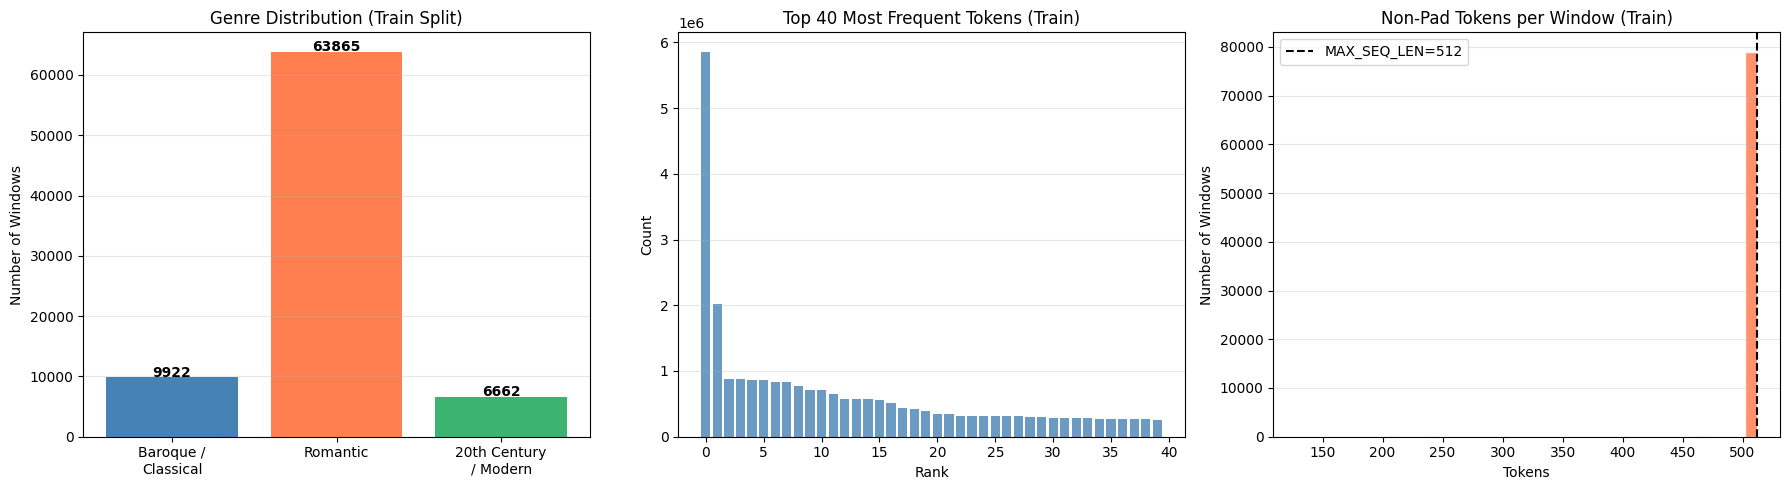

In [ ]:
train_tokens = np.load(tokenized_path / 'tokens_train.npy')
train_genres = np.load(tokenized_path / 'genres_train.npy')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

genre_labels = ['Baroque /\nClassical', 'Romantic', '20th Century\n/ Modern']
genre_counts = np.bincount(train_genres, minlength=NUM_GENRES)
axes[0].bar(genre_labels, genre_counts, color=['steelblue', 'coral', 'mediumseagreen'])
axes[0].set_title('Genre Distribution (Train Split)')
axes[0].set_ylabel('Number of Windows')
axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(genre_counts):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

flat_tokens = train_tokens.flatten()
unique, counts = np.unique(flat_tokens[flat_tokens != PAD_ID], return_counts=True)
top_k = 40
top_idx = np.argsort(counts)[::-1][:top_k]
axes[1].bar(range(top_k), counts[top_idx], color='steelblue', alpha=0.8)
axes[1].set_title(f'Top {top_k} Most Frequent Tokens (Train)')
axes[1].set_xlabel('Rank')
axes[1].set_ylabel('Count')
axes[1].grid(True, alpha=0.3, axis='y')

seq_lengths = (train_tokens != PAD_ID).sum(axis=1)
axes[2].hist(seq_lengths, bins=40, color='coral', edgecolor='white', alpha=0.85)
axes[2].set_title('Non-Pad Tokens per Window (Train)')
axes[2].set_xlabel('Tokens')
axes[2].set_ylabel('Number of Windows')
axes[2].axvline(MAX_SEQ_LEN, color='black', linestyle='--', label=f'MAX_SEQ_LEN={MAX_SEQ_LEN}')
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plot_save = plots_path / 'tokenization_eda.png'
plt.savefig(plot_save, dpi=150)
print(f'EDA plot saved to {plot_save}')
plt.show()

### PyTorch Dataset (Ready for Tasks 3 & 4)

In [ ]:
class TokenDataset(Dataset):
    def __init__(self, tokens_file, genres_file):
        self.tokens = torch.from_numpy(np.load(tokens_file)).long()
        self.genres = torch.from_numpy(np.load(genres_file)).long()

    def __len__(self):
        return len(self.tokens)

    def __getitem__(self, idx):
        seq   = self.tokens[idx]       
        genre = self.genres[idx]     
        input_ids  = seq[:-1]          
        target_ids = seq[1:]          
        return input_ids, target_ids, genre

In [41]:
train_ds = TokenDataset(
    tokenized_path / 'tokens_train.npy',
    tokenized_path / 'genres_train.npy'
)
val_ds = TokenDataset(
    tokenized_path / 'tokens_validation.npy',
    tokenized_path / 'genres_validation.npy'
)
test_ds = TokenDataset(
    tokenized_path / 'tokens_test.npy',
    tokenized_path / 'genres_test.npy'
)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

inp, tgt, gen = next(iter(train_loader))
print('Train dataset size :', len(train_ds))
print('Val   dataset size :', len(val_ds))
print('Test  dataset size :', len(test_ds))
print(f'Batch shapes -> input_ids: {inp.shape}, target_ids: {tgt.shape}, genre: {gen.shape}')
print(f'Sample genres in batch: {gen[:8].tolist()}')

Train dataset size : 80449
Val   dataset size : 9103
Test  dataset size : 10487
Batch shapes -> input_ids: torch.Size([32, 511]), target_ids: torch.Size([32, 511]), genre: torch.Size([32])
Sample genres in batch: [2, 1, 0, 1, 2, 1, 1, 1]
WE GOT THIS - TokenDataset is working and ready for Tasks 3 & 4!
